#### Importing Dataset

In [1]:
import pandas as pd

In [2]:
banks_sentiment = pd.read_csv('../data/processed/banks_sentiment.csv')

#### Thematic Analysis

##### TF-IDF n-grams

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
texts = banks_sentiment['cleaned_review'].fillna('')

In [13]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=5,  # Minimum document frequency
    max_df=0.8,  # Maximum document frequency
)

In [14]:
tfidf_matrix = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

In [25]:
scores = tfidf_matrix.mean(axis=0).A1 # the mean TF-IDF scores
top_idx = scores.argsort()[::-1]  # Get indices of top 25 features

top_phrases = pd.DataFrame({
    "phrase": feature_names[top_idx],
    "score": scores[top_idx]
})
top_phrases.shape

(647, 2)

In [26]:
top_phrases.head()

,phrase,score
0,app,0.082841
1,bank,0.037244
2,good,0.035201
3,use,0.029942
4,banking,0.028977


In [27]:
def top_phrase_for_row(row):
    if row.nnz == 0:
        return None
    idx = row.indices[row.data.argmax()]
    return feature_names[idx]

themes = [top_phrase_for_row(tfidf_matrix[i]) for i in range(tfidf_matrix.shape[0])]
banks_sentiment['theme'] = themes

In [29]:
banks_sentiment.tail(10)

,bank,cleaned_review,rating,sentiment_label,sentiment_score,theme
1259,DASHEN,love bug confirmation password please make fun...,5,positive,0.716415,please make
1260,DASHEN,dashen bank always one step ahead,5,positive,0.999602,bank always
1261,DASHEN,wow dashen super app,5,positive,0.999432,wow
1262,DASHEN,look good simple use,5,positive,0.999572,simple use
1263,DASHEN,best banking app ever seen,5,positive,0.999572,best banking
1264,DASHEN,applause dashen bank one best super app inorde...,5,positive,0.975089,one
1265,DASHEN,really app look like amazing wait activate mor...,5,positive,0.999345,activate
1266,DASHEN,nice wish nice app,5,positive,0.999331,nice
1267,DASHEN,dashen bank always one step ahead,5,positive,0.999602,bank always
1268,DASHEN,app make difference,5,positive,0.999416,app make


In [33]:
import spacy
from collections import Counter

In [40]:
nlp = spacy.load("en_core_web_sm")

def extract_noun_phrases(text):
    phrases = []
    for doc in nlp.pipe(texts, batch_size=50):
        phrases.extend(
            chunk.text.lower().strip()
            for chunk in doc.noun_chunks 
            if len(chunk.text) > 1 
            and not chunk.text.isspace() 
            and len(chunk.text.split()) <= 4
        )
    return Counter(phrases)

phrase_counts = extract_noun_phrases(banks_sentiment['cleaned_review'].fillna(''))
phrase_counts.most_common(20)

[('app', 129),
 ('money', 24),
 ('bank', 21),
 ('transaction', 19),
 ('dashen bank', 19),
 ('worst app', 16),
 ('everything', 15),
 ('update', 13),
 ('work', 13),
 ('developer option', 12),
 ('cbe', 11),
 ('application', 11),
 ('dashen super app', 11),
 ('problem', 10),
 ('good app', 10),
 ('error', 10),
 ('time', 10),
 ('best app', 9),
 ('use', 9),
 ('mobile banking', 9)]

#### Grouping related keywords into 3-5 overarching themes per bank

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

In [43]:
N_CANDIDATES = 200
vectorizer_all = vectorizer
feat = vectorizer_all.get_feature_names_out()

In [45]:
def top_phrases_for_bank(bank_name, top_n=N_CANDIDATES):
    mask = banks_sentiment['bank'] == bank_name
    Xb = vectorizer_all.transform(banks_sentiment.loc[mask,'cleaned_review'].fillna(''))
    bank_scores = Xb.mean(axis=0).A1
    idx = bank_scores.argsort()[::-1][:top_n]
    return list(feat[idx])

banks = banks_sentiment['bank'].unique()

In [46]:
from sentence_transformers import SentenceTransformer

c:\Users\Administrator\KAIM_projects\fintech-review-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
model = SentenceTransformer('all-MiniLM-L6-v2')

c:\Users\Administrator\KAIM_projects\fintech-review-analytics\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Administrator\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00

In [48]:
themes_per_bank = {}

for bank in banks:
    phrases = top_phrases_for_bank(bank)
    if not phrases:
        continue
    emb = model.encode(phrases, show_progress_bar=True)
    
    n_clusters = 4
    km = KMeans(n_clusters=n_clusters, random_state=42)
    km.fit(emb)
    labels = km.labels_
    
    centers = km.cluster_centers_
    closest, _ = pairwise_distances_argmin_min(centers, emb)
    cluster_representatives = [phrases[i] for i in closest]
    
    phrase2cluster = dict(zip(phrases, labels))
    
    phrase2cluster = dict(zip(phrases, labels))
    cluster_info = {i: {'repr': cluster_representatives[i],
                        'members': [p for p,l in zip(phrases,labels) if l==i]}
                    for i in range(n_clusters)}
    themes_per_bank[bank] = {'phrase2cluster': phrase2cluster, 'clusters': cluster_info}
    

Batches: 100%|██████████| 7/7 [00:00<00:00, 17.09it/s]


#### Visualization

In [61]:
# create human-readable labels per bank
cluster_label_map = {}
for bank, info in themes_per_bank.items():
    cluster_label_map[bank] = {}
    for cid, cinfo in info['clusters'].items():
        repr_phrase = cinfo['repr']
        cluster_label_map[bank][cid] = f"{cid}: {repr_phrase[:40]}"

# map review -> labeled theme
def map_theme_label(row):
    bank = row['bank']
    cid = row.get('theme_cluster')
    if pd.isna(cid) or cid is None:
        return "other"
    return cluster_label_map.get(bank, {}).get(int(cid), str(cid))

banks_sentiment['theme_label'] = banks_sentiment.apply(map_theme_label, axis=1)

In [62]:
for bank, info in themes_per_bank.items():
    print(f"\nBank: {bank}")
    for cid, cinfo in info['clusters'].items():
        members_sample = ", ".join(cinfo['members'][:5])
        print(f"  Cluster {cid}: repr='{cinfo['repr']}'  sample=[{members_sample}]")


Bank: CBE
  Cluster 0: repr='app'  sample=[app, application, use, mobile, good app]
  Cluster 1: repr='want'  sample=[good, working, please, thanks, nice]
  Cluster 2: repr='bank'  sample=[cbe, service, bank, transaction, transfer]
  Cluster 3: repr='easy'  sample=[update, easy, time, best, new]

Bank: BOA
  Cluster 0: repr='every time'  sample=[ever, always, sometimes, never, frequently]
  Cluster 1: repr='app'  sample=[app, mobile, mobile banking, banking app, application]
  Cluster 2: repr='working'  sample=[work, bank, banking, boa, working]
  Cluster 3: repr='get'  sample=[worst, please, good, time, best]

Bank: DASHEN
  Cluster 0: repr='bank'  sample=[bank, dashen bank, banking, transaction, account]
  Cluster 1: repr='fast'  sample=[dashen, easy, best, fast, feature]
  Cluster 2: repr='app'  sample=[app, super app, mobile, application, app ever]
  Cluster 3: repr='working'  sample=[super, use, one, good, user]


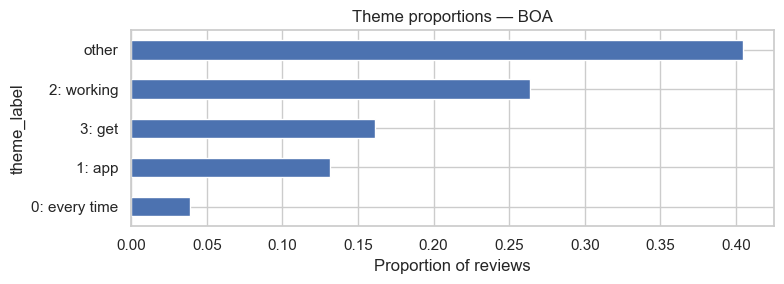

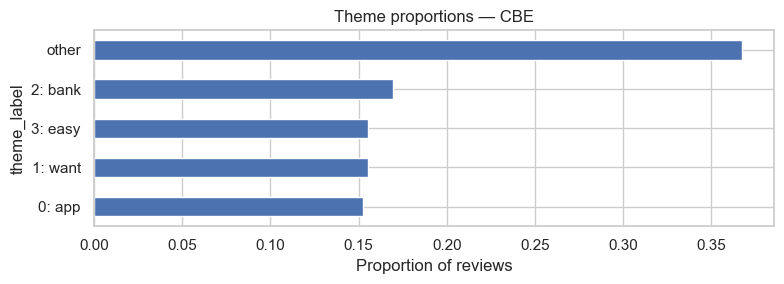

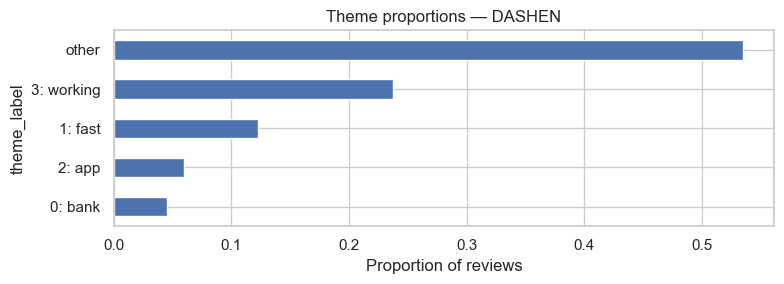

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
for bank in counts.index:
    bank_counts = banks_sentiment[banks_sentiment['bank'] == bank]['theme_label'].value_counts(normalize=True)
    bank_counts = bank_counts.sort_values(ascending=True)
    plt.figure(figsize=(8, max(3, len(bank_counts)*0.4)))
    bank_counts.plot(kind='barh', color='C0')
    plt.title(f"Theme proportions — {bank}")
    plt.xlabel("Proportion of reviews")
    plt.tight_layout()
    plt.show()

In [66]:
banks_sentiment.head()

,bank,cleaned_review,rating,sentiment_label,sentiment_score,theme,theme_cluster,theme_label
0,CBE,best app financial sector,5,positive,0.999521,financial,2.0,2: bank
1,CBE,nice get recently transaction please try keep ...,5,negative,0.932748,done,NaN,other
2,CBE,secure poor interface limited history service ...,1,negative,0.999277,idea,NaN,other
3,CBE,transaction fee hidden app show transaction fe...,3,negative,0.999785,fee,2.0,2: bank
4,CBE,app functional airtime wallet,5,positive,0.634094,airtime,0.0,0: app


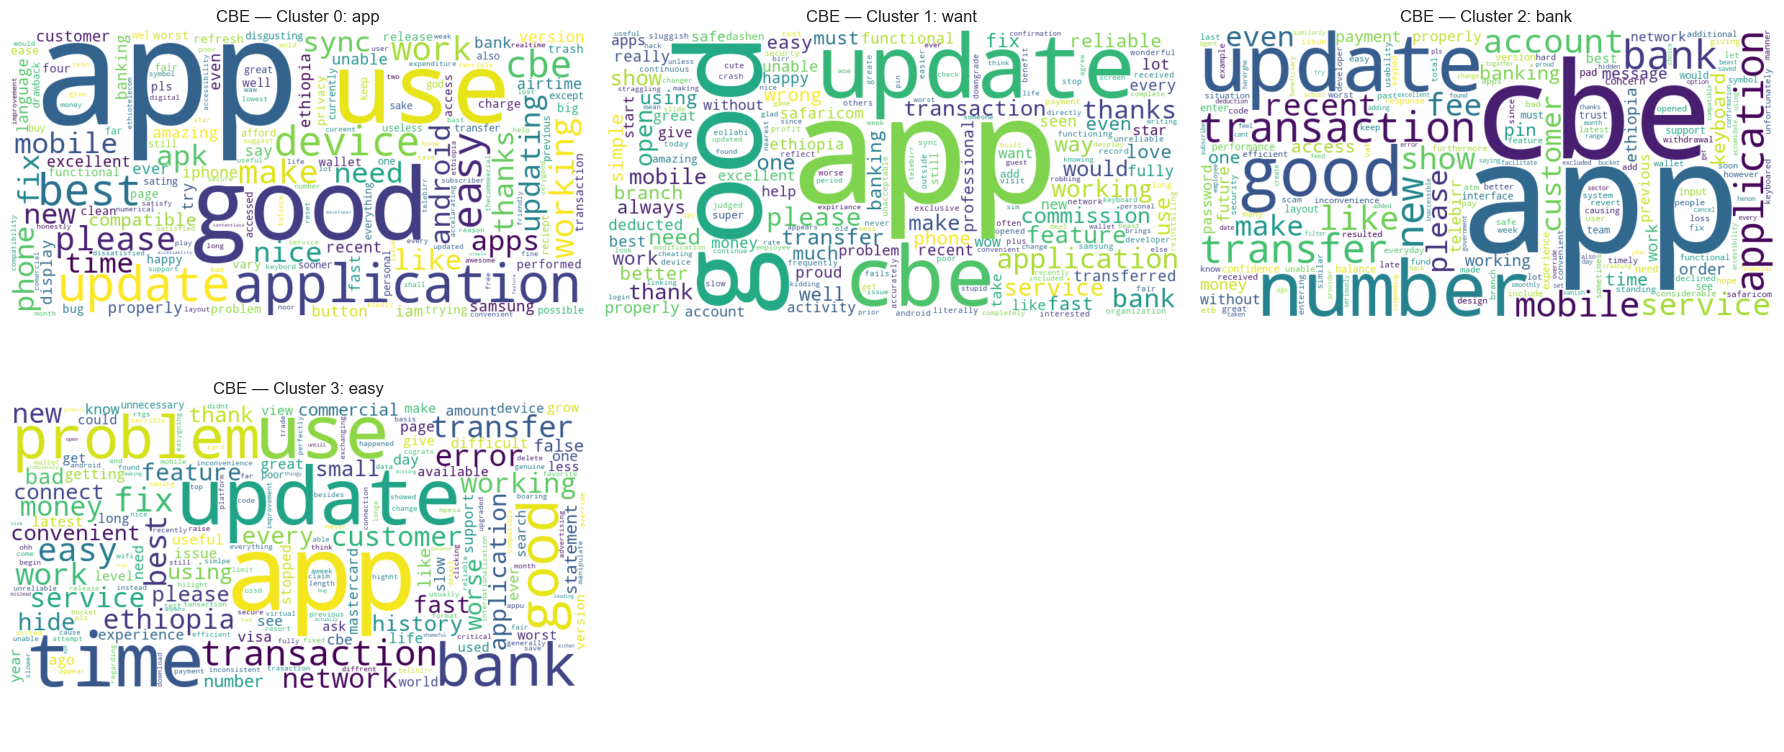

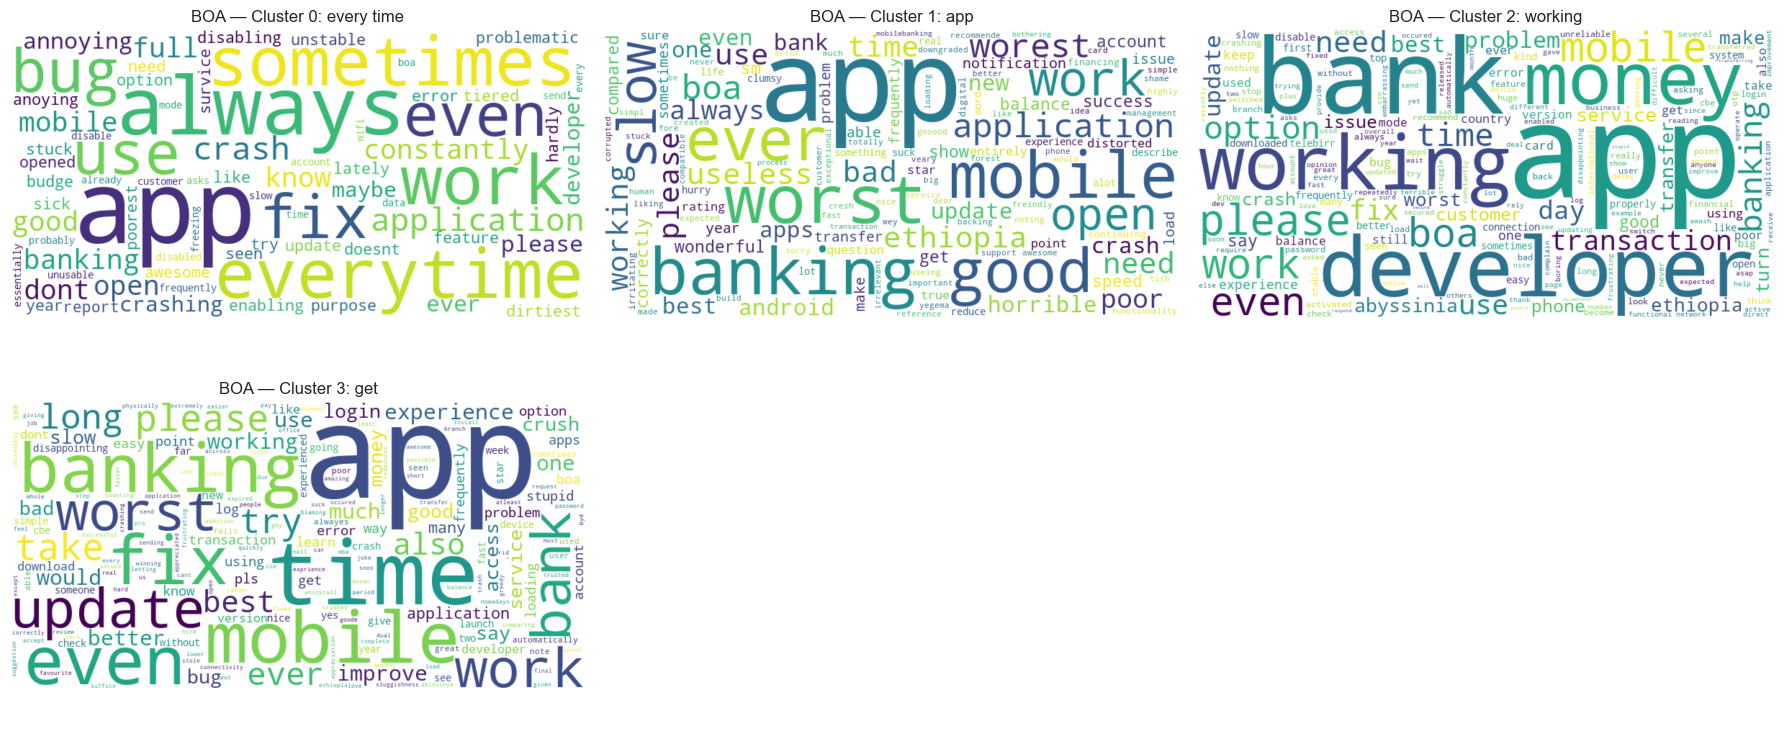

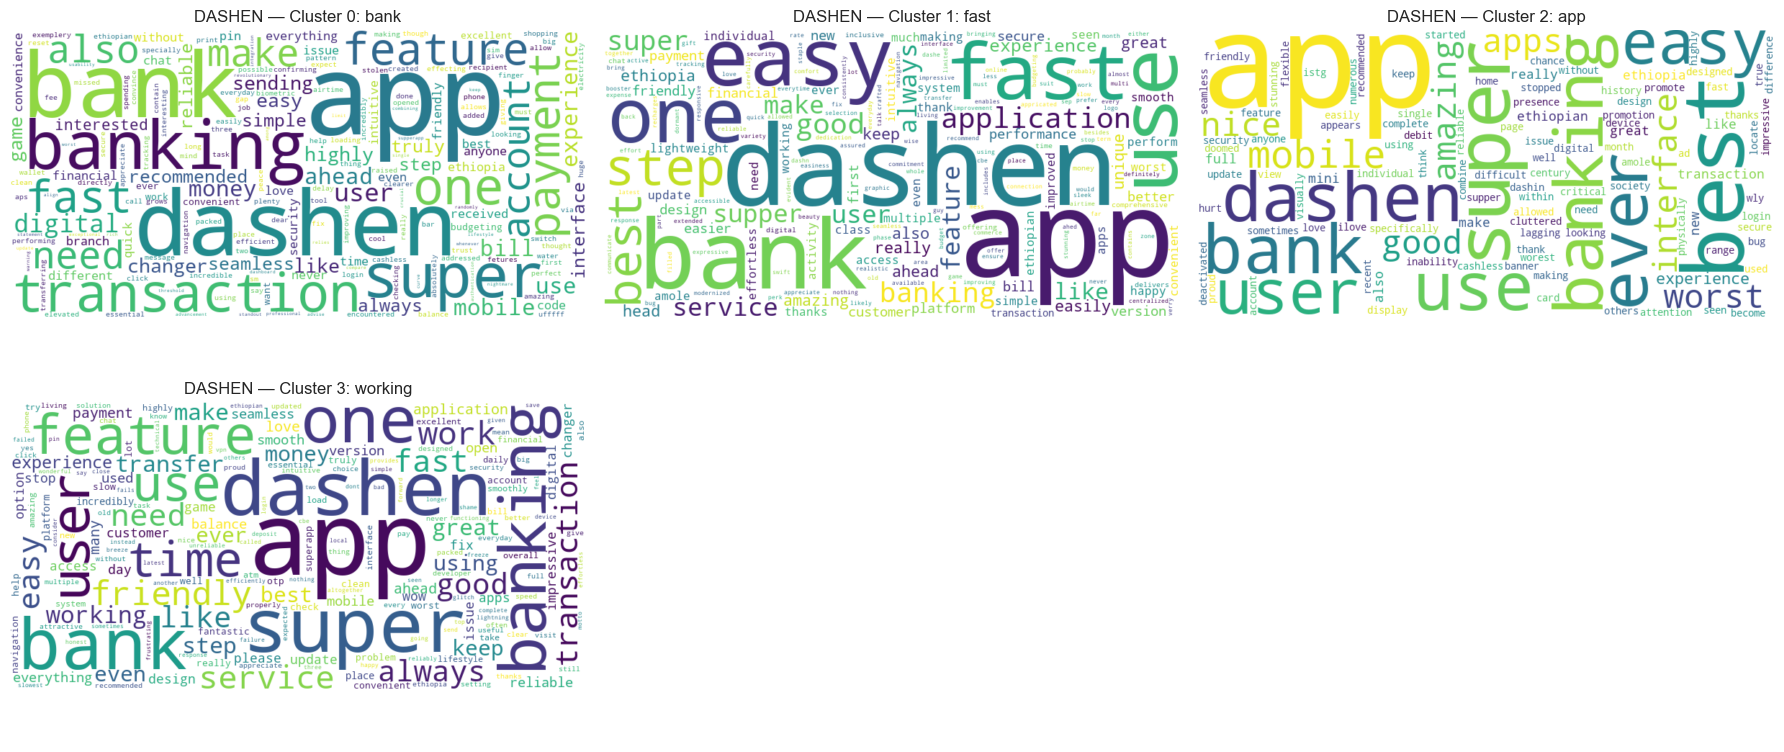

In [68]:
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

os.makedirs("outputs/wordclouds", exist_ok=True)

def words_from_texts(texts):
    text = " ".join(texts).lower()
    tokens = re.findall(r"\b[a-z]{2,}\b", text)   # keep alphabetic tokens length>=2
    return Counter(tokens)

for bank, info in themes_per_bank.items():
    clusters = info["clusters"]
    n = len(clusters)
    if n == 0:
        continue

    # subplot grid
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = axes.flatten() if n>1 else [axes]

    for i, (cid, cinfo) in enumerate(sorted(clusters.items())):
        # gather reviews assigned to this bank+cluster
        mask = (banks_sentiment["bank"] == bank) & (banks_sentiment["theme_cluster"] == cid)
        texts = banks_sentiment.loc[mask, "cleaned_review"].fillna("").tolist()

        if not texts:
            axes[i].axis("off")
            axes[i].set_title(f"{bank} - Cluster {cid}\n(no reviews)")
            continue

        freqs = words_from_texts(texts)
        wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freqs)

        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].axis("off")
        repr_phrase = cinfo.get("repr", "")[:40]
        axes[i].set_title(f"{bank} — Cluster {cid}: {repr_phrase}")

        # optional: save each wordcloud image
        wc.to_file(f"outputs/wordclouds/{bank}_cluster_{cid}.png")

    # hide any extra axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

#### Let's do LDA

In [74]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Prepare document-term matrix
texts = banks_sentiment['cleaned_review'].fillna('')
cv = CountVectorizer(max_df=0.95, min_df=5, stop_words='english')
dtm = cv.fit_transform(texts)

# Fit LDA
n_topics = 6
lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)
lda.fit(dtm)

# Show top words per topic
feature_names = cv.get_feature_names_out()
def show_topics(model, feature_names, no_top_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-no_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        topics[topic_idx] = top_words
        print(f"Topic {topic_idx}: ", ", ".join(top_words))
    return topics

topics = show_topics(lda, feature_names, no_top_words=10)

# Assign dominant topic and confidence to each document
doc_topic = lda.transform(dtm)
dominant_topic = doc_topic.argmax(axis=1)
topic_confidence = doc_topic.max(axis=1)
banks_sentiment['lda_topic'] = dominant_topic
banks_sentiment['lda_topic_confidence'] = topic_confidence

# Show a quick preview
banks_sentiment[['lda_topic','lda_topic_confidence']].head()

Topic 0:  app, mobile, banking, application, cbe, need, bank, better, good, thanks
Topic 1:  app, use, easy, developer, option, fast, phone, make, boa, seen
Topic 2:  app, user, banking, feature, transaction, friendly, super, experience, dashen, service
Topic 3:  app, bank, dashen, best, super, step, ethiopia, amazing, ahead, banking
Topic 4:  app, update, transaction, account, working, need, time, bank, transfer, slow
Topic 5:  app, work, worst, time, good, mobile, fix, banking, problem, version


,lda_topic,lda_topic_confidence
0,3,0.790948
1,4,0.860939
2,5,0.533757
3,4,0.906825
4,1,0.397287


In [75]:
banks_sentiment.head()

,bank,cleaned_review,rating,sentiment_label,sentiment_score,theme,theme_label,lda_topic,lda_topic_confidence
0,CBE,best app financial sector,5,positive,0.999521,financial,2: bank,3,0.790948
1,CBE,nice get recently transaction please try keep ...,5,negative,0.932748,done,other,4,0.860939
2,CBE,secure poor interface limited history service ...,1,negative,0.999277,idea,other,5,0.533757
3,CBE,transaction fee hidden app show transaction fe...,3,negative,0.999785,fee,2: bank,4,0.906825
4,CBE,app functional airtime wallet,5,positive,0.634094,airtime,0: app,1,0.397287


#### Saving to csv

In [71]:
banks_sentiment.drop(columns=['theme_cluster'], inplace=True)

In [73]:
banks_sentiment.to_csv('../data/processed/banks_sentiment_with_themes.csv', index=False)